# Diffusion: generation of MNIST digits

In [31]:
import os
import numpy as np
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary
from denoising_diffusion_pytorch import Unet, GaussianDiffusion

import diffusion as diff
import helper as dl

In [48]:
# If the kernel is not restarted, packages are not reloaded by default
# This is to make sure the changes in the python scripts are loaded
import importlib

importlib.reload(diff)
importlib.reload(dl);

### File paths and flags

In [33]:
DATA_PATH = "../datasets/mnist"
PLOT_PATH = "/mnt/Datos/LaTeX/deep-learning/ex7/figures"
MODEL_PATH = "models"
LOG_PATH = "logs"

if not os.path.exists(DATA_PATH):
    raise Exception("Data folder does not exist")
if not os.path.exists(PLOT_PATH):
    raise Exception("Plots folder does not exist")
if not os.path.exists(MODEL_PATH):
    raise Exception("Model folder does not exist")
if not os.path.exists(LOG_PATH):
    raise Exception("Log folder does not exist")

In [50]:
# Flags
TRAIN = False # Set to False to load a pre-trained model and skip training
SAVE_LOGS = True
SAVE_MODEL = True
SAVE_PLOTS = True

# Model name
SAVE_MODEL_NAME = "diffusion.pth"
LOAD_MODEL_NAME = "diffusion1.pth"
LOG_NAME = "diffusion"

if not SAVE_LOGS:
    LOG_PATH = None
else:
    LOG_PATH = os.path.join(LOG_PATH, LOG_NAME)

if not SAVE_PLOTS:
    PLOT_PATH = None

### Hyperparameter selection

In [36]:
# General hyperparameters
learning_rate = 4e-4
batch_size = 128
num_epochs = 2
patience = 30

# Model hyperparameters. We use a dictionary to save them together with the model
model_hyperparams = {
        'time_steps': 1000,
        'sampling_timesteps': 250,
        'image_size': 28,
        'dim': 32,
        'dim_mults': (1, 2, 5),
    }

### Loading data

In [37]:
# Load the data
train_loader, test_loader = diff.load_mnist_data(DATA_PATH, batch_size=batch_size)

### Definition of the model

In [38]:
# We create a class as usual to be able to use the model saving functions
class diffusion(nn.Module):
    def __init__(self, image_size, dim, dim_mults, time_steps, sampling_timesteps):
        super().__init__()
        
        self.unet = Unet(
            dim=dim,
            dim_mults=dim_mults,
            flash_attn=False,
            channels=1
        )

        self.diffusion = GaussianDiffusion(
            self.unet,
            image_size=image_size,
            timesteps=time_steps,
            sampling_timesteps=sampling_timesteps
        )

    def forward(self, x):
        return self.diffusion(x)
    
    def sample(self, batch_size=1):
        return self.diffusion.sample(batch_size=batch_size)

### Training the neural network

In [39]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

Using device: xpu


In [40]:
if TRAIN:
    model = diffusion(**model_hyperparams).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate)

    print(f'Learning rate: {learning_rate}\n')
    summary(model);

Learning rate: 0.0004

Layer (type:depth-idx)                        Param #
├─Unet: 1-1                                   --
|    └─Conv2d: 2-1                            1,600
|    └─Sequential: 2-2                        --
|    |    └─SinusoidalPosEmb: 3-1             --
|    |    └─Linear: 3-2                       4,224
|    |    └─GELU: 3-3                         --
|    |    └─Linear: 3-4                       16,512
|    └─ModuleList: 2-3                        --
|    |    └─ModuleList: 3-5                   75,264
|    |    └─ModuleList: 3-6                   79,392
|    |    └─ModuleList: 3-7                   307,232
|    └─ModuleList: 2-4                        --
|    |    └─ModuleList: 3-8                   1,437,248
|    |    └─ModuleList: 3-9                   282,720
|    |    └─ModuleList: 3-10                  102,976
|    └─ResnetBlock: 2-5                       --
|    |    └─Sequential: 3-11                  41,280
|    |    └─Block: 3-12                       

In [41]:
if TRAIN:
    # Train the model
    train_losses, val_losses = diff.train_diffusion_model(train_loader, test_loader, model, optimizer,
                num_epochs=num_epochs, patience=patience, device=device, PATH=LOG_PATH)

Training diffusion model on xpu.
Epoch [1/2] -> Train Loss: 0.1645, Val Loss: 0.0879, Time: 201.78 seconds


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Epoch [2/2] -> Train Loss: 0.0789, Val Loss: 0.0700, Time: 204.41 seconds


sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

Training complete.


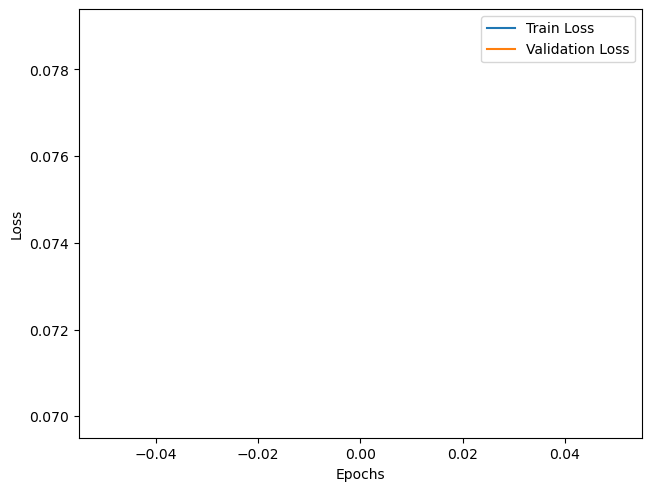

In [43]:
# Plot training/validation loss
if TRAIN:
    dl.plot_losses(train_losses, val_losses, PATH=PLOT_PATH)

In [44]:
# Save model
if TRAIN and SAVE_MODEL:
    hyperparams = {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs': num_epochs,
        'patience': patience,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'model_hyperparams': model_hyperparams
    }
    dl.save_model(model, hyperparams, PATH=f"{MODEL_PATH}/{SAVE_MODEL_NAME}")

### Evaluating the model

Learining rate: 0.0004
Layer (type:depth-idx)                        Param #
├─Unet: 1-1                                   --
|    └─Conv2d: 2-1                            1,600
|    └─Sequential: 2-2                        --
|    |    └─SinusoidalPosEmb: 3-1             --
|    |    └─Linear: 3-2                       4,224
|    |    └─GELU: 3-3                         --
|    |    └─Linear: 3-4                       16,512
|    └─ModuleList: 2-3                        --
|    |    └─ModuleList: 3-5                   75,264
|    |    └─ModuleList: 3-6                   79,392
|    |    └─ModuleList: 3-7                   307,232
|    └─ModuleList: 2-4                        --
|    |    └─ModuleList: 3-8                   1,437,248
|    |    └─ModuleList: 3-9                   282,720
|    |    └─ModuleList: 3-10                  102,976
|    └─ResnetBlock: 2-5                       --
|    |    └─Sequential: 3-11                  41,280
|    |    └─Block: 3-12                       

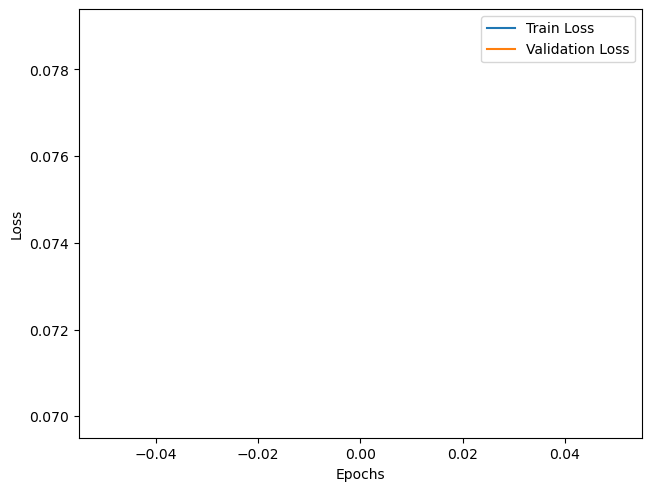

In [46]:
# Load model if it was not trained in this run
if not TRAIN:
    model, info = dl.load_model(diffusion, PATH=f"{MODEL_PATH}/{LOAD_MODEL_NAME}")
    print('Learining rate:', info['learning_rate'])
    summary(model);
    dl.plot_losses(info['train_losses'], info['val_losses'], PATH=PLOT_PATH)

sampling loop time step:   0%|          | 0/250 [00:00<?, ?it/s]

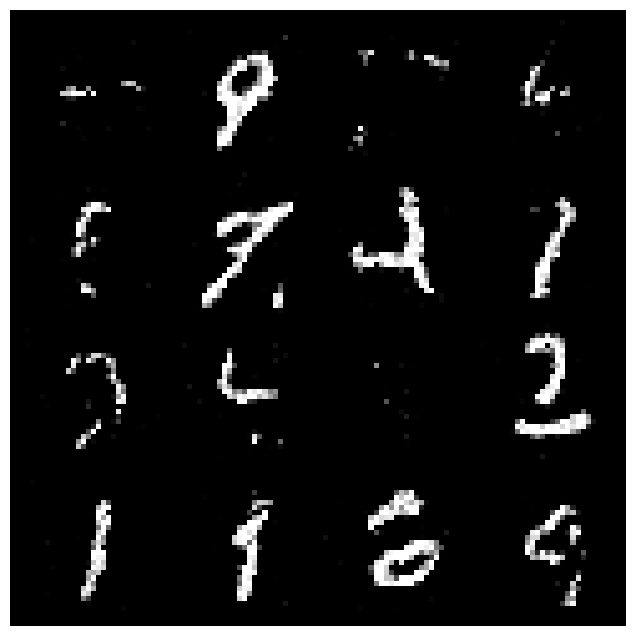

In [52]:
diff.visualize_generated_images(model, device, shape=(4, 4), PATH=PLOT_PATH)